# 1. Import Library

In [1]:
#mengimpor library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Baca Dataset

In [2]:
#membaca dataset
df=pd.read_csv("https://raw.githubusercontent.com/yyunitasa-stack/Amazon-E-Commerce-Sales-Performance-Analysis/main/Dataset/Amazon%20Sale%20Report%20Cleaned.csv")

C:\Users\YUNITA\AppData\Local\Temp\ipykernel_7880\1635806414.py:2: DtypeWarning: Columns (0: unnamed:22) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv("https://raw.githubusercontent.com/yyunitasa-stack/Amazon-E-Commerce-Sales-Performance-Analysis/main/Dataset/Amazon%20Sale%20Report%20Cleaned.csv")


In [3]:
#menampilkan 5 baris pertama dari dataset
df.head()

,order_id,date,status,fulfilment,sales_channel,ship_service_level,style,SKU,category,size,ASIN,courier_status,qty,amount,ship_state,ship_postal_code,promotion_ids,B2B,fulfilled_by,unnamed:22
0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,S,B09KXVBD7Z,Shipped,0,647.62,MAHARASHTRA,400081.0,NaN,False,Easy Ship,NaN
1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,3XL,B09K3WFS32,Shipped,1,406.00,KARNATAKA,560085.0,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,XL,B07WV4JV4D,Shipped,1,329.00,MAHARASHTRA,410210.0,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,L,B099NRCT7B,Shipped,0,753.33,PUDUCHERRY,605008.0,NaN,False,Easy Ship,NaN
4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,3XL,B098714BZP,Shipped,1,574.00,TAMIL NADU,600073.0,NaN,False,NaN,NaN


In [4]:
#menampilkan ukuran dataset
df.shape
#Interpretasi: dataset memiliki 128.158 baris dan 13 kolom

(128936, 20)

# 3. Data Preparation

In [5]:
#memeriksa tipe data dari setiap kolom
df.dtypes
#Interpretasi: kolom date memiliki tipe data string, sehingga perlu diubah menjadi tipe data datetime

order_id                  str
date                      str
status                    str
fulfilment                str
sales_channel             str
ship_service_level        str
style                     str
SKU                       str
category                  str
size                      str
ASIN                      str
courier_status            str
qty                     int64
amount                float64
ship_state                str
ship_postal_code      float64
promotion_ids             str
B2B                      bool
fulfilled_by              str
unnamed:22             object
dtype: object

In [6]:
#mengatasi masalah tipe data pada kolom date
df['date'] = pd.to_datetime(df['date'])

In [7]:
#memeriksa nilai minimum dan maksimum dari kolom date
df[['date']].describe()
#Interpretasi: periode waktu dari dataset adalah mulai 31-03-2022 hingga 29-06-2022 (trimester 2 tahun 2022)

,date
count,128936
mean,2022-05-12 11:51:28.043680
min,2022-03-31 00:00:00
25%,2022-04-20 00:00:00
50%,2022-05-10 00:00:00
75%,2022-06-04 00:00:00
max,2022-06-29 00:00:00


In [8]:
#membuat kolom baru (month)
df['month_num']=df['date'].dt.month
df['month']=df['date'].dt.month_name()

# 4. Univariate Analysis

In [9]:
#mengetahui jumlah transaksi berdasarkan order_id
df['order_id'].nunique()
#Interpretasi: terdapat 120.350 transaksi unik pada dataset

120350

## 4.1 Numerical Analysis

In [10]:
#menampilkan statistik deskriptif dari kolom qty dan amount
df[['qty','amount']].describe()

,qty,amount
count,128936.000000,128936.000000
mean,0.904464,645.935366
std,0.313316,272.790115
min,0.000000,0.000000
25%,1.000000,459.000000
50%,1.000000,605.000000
75%,1.000000,771.000000
max,15.000000,5584.000000


In [11]:
#menampilkan jumlah produk terjual (quantity) dan total penjualan (amount)
df[['qty','amount']].sum()

qty         116618.0
amount    83284322.3
dtype: float64

## 4.2 Categorical Analysis

Fulfilment

In [12]:
#mengetahui distribusi transaksi berdasarkan fulfilment
df['fulfilment'].value_counts()

fulfilment
Amazon      89672
Merchant    39264
Name: count, dtype: int64

Sales Channel

In [13]:
#mengetahui distribusi transaksi berdasarkan sales channel
df['sales_channel'].value_counts()

sales_channel
Amazon.in     128812
Non-Amazon       124
Name: count, dtype: int64

Ship Service Level

In [14]:
#mengetahui distribusi transaksi berdasarkan ship service level
df['ship_service_level'].value_counts()

ship_service_level
Expedited    88589
Standard     40347
Name: count, dtype: int64

Category

In [15]:
#mengetahui distribusi transaksi berdasarkan category
df['category'].value_counts()

category
Set              50269
kurta            49856
Western Dress    15499
Top              10620
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

Size

In [16]:
#mengetahui distribusi transaksi berdasarkan size
df['size'].value_counts()

size
M       22702
L       22121
XL      20871
XXL     18093
S       17084
3XL     14814
XS      11160
6XL       738
5XL       550
4XL       425
Free      378
Name: count, dtype: int64

Courier Status

In [17]:
#mengetahui distribusi transaksi berdasarkan courier status
df['courier_status'].value_counts()

courier_status
Shipped      116327
Unshipped      6679
Cancelled      5930
Name: count, dtype: int64

Status

In [18]:
#mengetahui distribusi transaksi berdasarkan status
df['status'].value_counts()

status
Shipped                          77785
Shipped - Delivered to Buyer     28762
Cancelled                        18322
Shipped - Returned to Seller      1950
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

Ship State

In [19]:
#mengetahui distribusi transaksi berdasarkan ship state
df['ship_state'].value_counts()

ship_state
MAHARASHTRA          22259
KARNATAKA            17325
TAMIL NADU           11483
TELANGANA            11330
UTTAR PRADESH        10637
DELHI                 7048
KERALA                6584
WEST BENGAL           5962
ANDHRA PRADESH        5431
GUJARAT               4489
HARYANA               4415
RAJASTHAN             2718
MADHYA PRADESH        2529
ODISHA                2139
BIHAR                 2114
PUNJAB                1918
ASSAM                 1663
UTTARAKHAND           1553
JHARKHAND             1456
GOA                   1137
CHHATTISGARH           909
HIMACHAL PRADESH       788
JAMMU & KASHMIR        702
PUDUCHERRY             351
CHANDIGARH             333
MANIPUR                316
ANDAMAN & NICOBAR      257
MEGHALAYA              207
SIKKIM                 205
NAGALAND               187
TRIPURA                151
ARUNACHAL PRADESH      147
MIZORAM                 76
DADRA AND NAGAR         70
LADAKH                  43
LAKSHADWEEP              4
Name: count, dtyp

B2B

In [20]:
#mengetahui distribusi transaksi berdasarkan business to business (B2B)
df['B2B'].value_counts()

B2B
False    128065
True        871
Name: count, dtype: int64

## 4.3 Time Analysis

In [21]:
df['month'].value_counts()

month
April    49052
May      42025
June     37688
March      171
Name: count, dtype: int64

In [22]:
df.columns

Index(['order_id', 'date', 'status', 'fulfilment', 'sales_channel',
       'ship_service_level', 'style', 'SKU', 'category', 'size', 'ASIN',
       'courier_status', 'qty', 'amount', 'ship_state', 'ship_postal_code',
       'promotion_ids', 'B2B', 'fulfilled_by', 'unnamed:22', 'month_num',
       'month'],
      dtype='str')

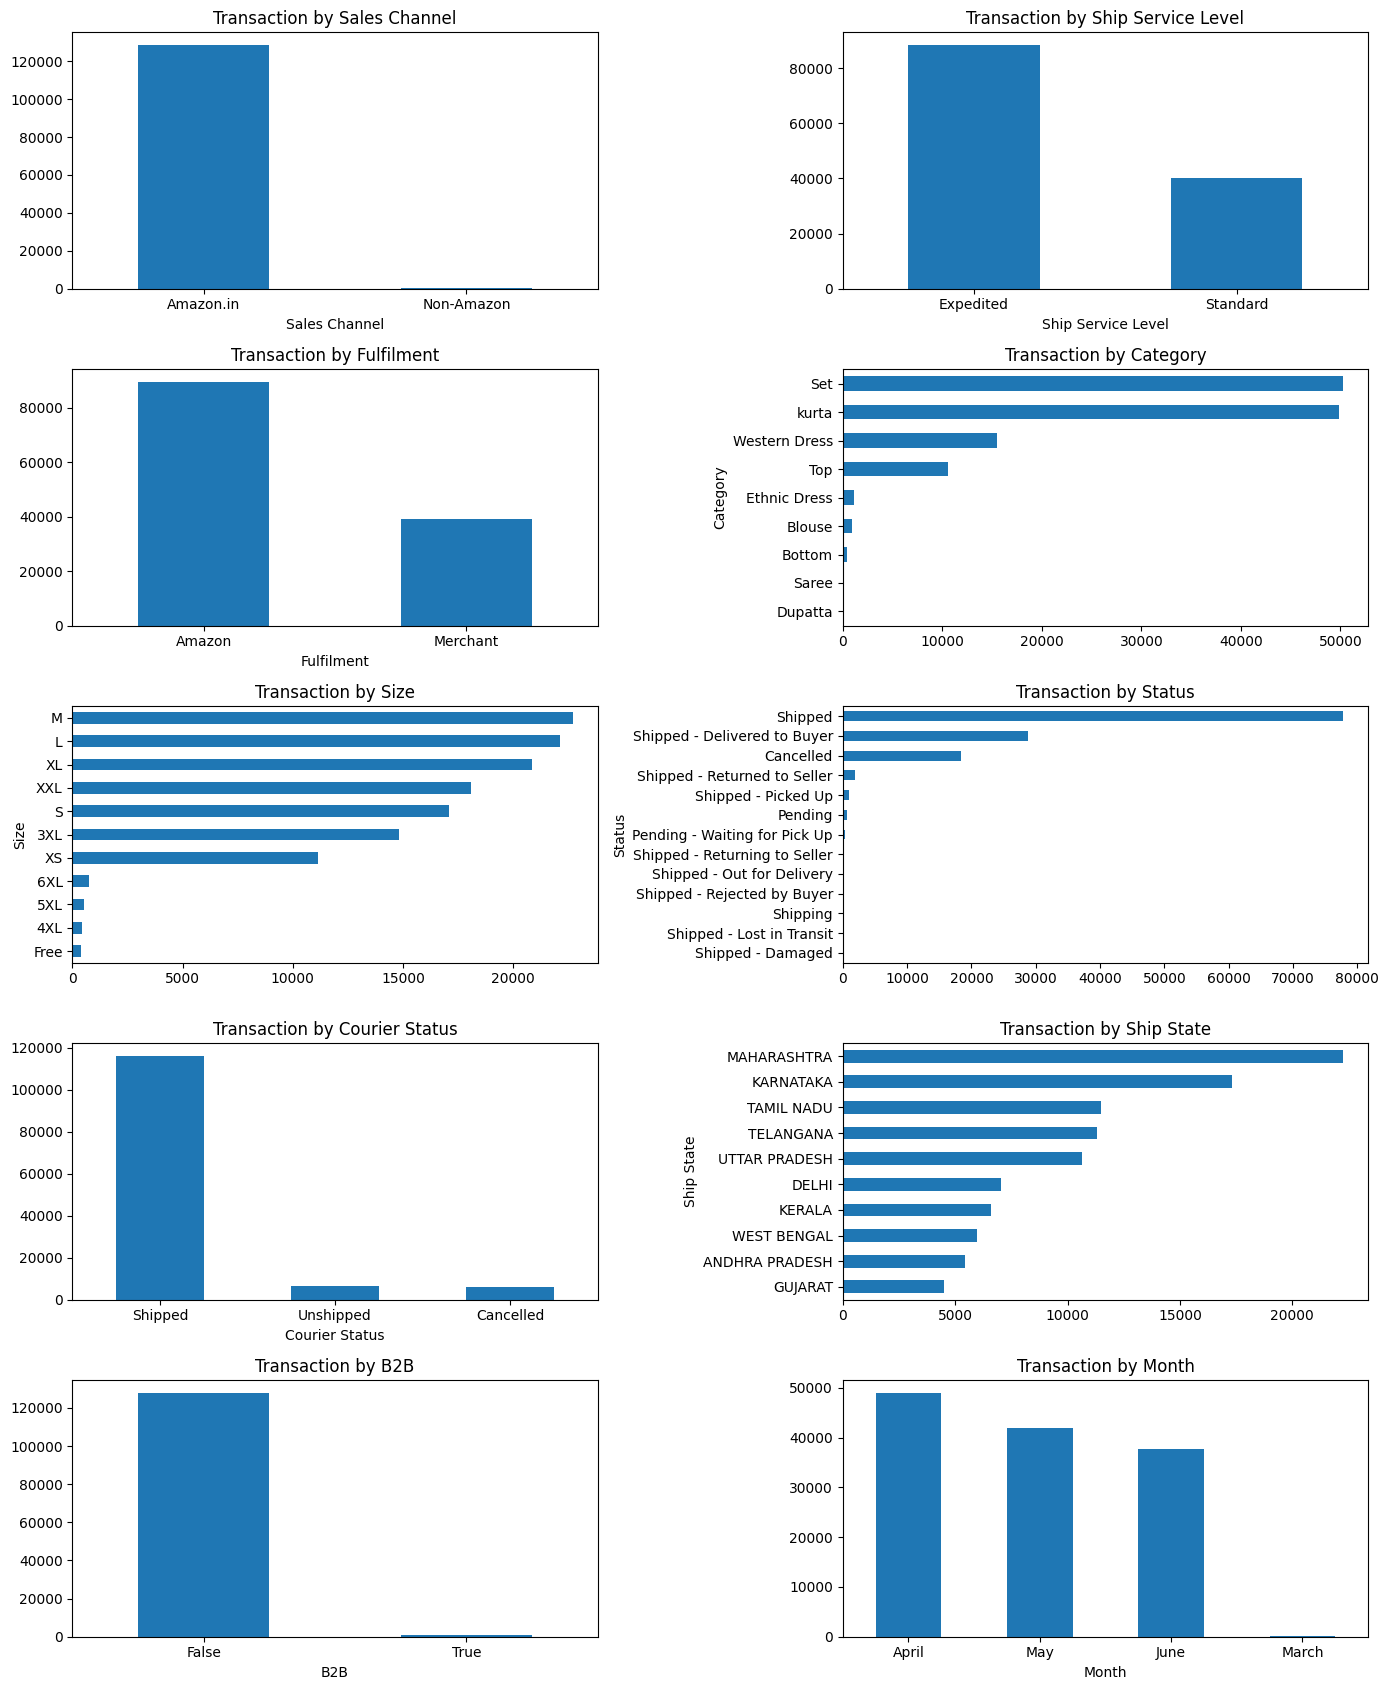

In [23]:
fig, axes = plt.subplots(5, 2, figsize=(14, 17))

#menampilkan plot distribusi transaksi berdasarkan sales channel
df['sales_channel'].value_counts().plot(
    kind='bar',
    ax=axes[0, 0]
)
axes[0, 0].set_title('Transaction by Sales Channel')
axes[0, 0].set_xlabel('Sales Channel')
axes[0, 0].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan ship service level
df['ship_service_level'].value_counts().plot(
    kind='bar',
    ax=axes[0, 1]
)
axes[0, 1].set_title('Transaction by Ship Service Level')
axes[0, 1].set_xlabel('Ship Service Level')
axes[0, 1].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan fulfilment
df['fulfilment'].value_counts().plot(
    kind='bar',
    ax=axes[1, 0]
)
axes[1, 0].set_title('Transaction by Fulfilment')
axes[1, 0].set_xlabel('Fulfilment')
axes[1, 0].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan category
df['category'].value_counts().sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[1, 1]
)
axes[1, 1].set_title('Transaction by Category')
axes[1, 1].set_ylabel('Category')
axes[1, 1].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan size
df['size'].value_counts().sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[2, 0]
)
axes[2, 0].set_title('Transaction by Size')
axes[2, 0].set_ylabel('Size')
axes[2, 0].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan status
df['status'].value_counts().sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[2, 1]
)
axes[2, 1].set_title('Transaction by Status')
axes[2, 1].set_ylabel('Status')
axes[2, 1].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan courier status
df['courier_status'].value_counts().plot(
    kind='bar',
    ax=axes[3, 0]
)
axes[3, 0].set_title('Transaction by Courier Status')
axes[3, 0].set_xlabel('Courier Status')
axes[3, 0].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan ship state (top 10)
df['ship_state'].value_counts().head(10).sort_values(ascending=True).plot(
    kind='barh',
    ax=axes[3, 1]
)
axes[3, 1].set_title('Transaction by Ship State')
axes[3, 1].set_ylabel('Ship State')
axes[3, 1].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan B2B
df['B2B'].value_counts().plot(
    kind='bar',
    ax=axes[4, 0]
)
axes[4, 0].set_title('Transaction by B2B')
axes[4, 0].tick_params(axis='x', rotation=0)

#menampilkan plot distribusi transaksi berdasarkan Month
df['month'].value_counts().plot(
    kind='bar',
    ax=axes[4, 1]
)
axes[4, 1].set_title('Transaction by Month')
axes[4, 1].set_xlabel('Month')
axes[4, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# 5. Bivariate Analysis

Sales Trend Over Time

           Monthly Sales
----------------------------------
   month_num  month       amount
0          3  March    107128.85
1          4  April  30644434.32
2          5    May  27732088.75
3          6   June  24800670.38


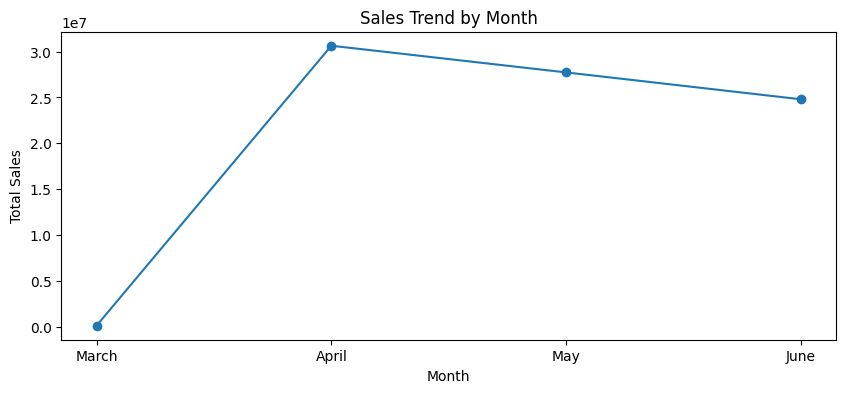


Interpretasi:
- Penjualan pada bulan Maret memiliki nilai penjualan terendah, karena dataset hanya mencakup satu hari pada bulan Maret (31 Maret 2022)
- Penjualan naik pada bulan April hingga mencapai penjualan tertinggi senilai 30,4 juta Rupee, lalu linear menurun hingga bulan Juni


In [24]:
#melakukan grouping data berdasarkan bulan dan aggregation dengan menghitung total penjualan (amount)
monthlySales=df.groupby(['month_num','month'])['amount'].sum().reset_index().sort_values('month_num')
print("           Monthly Sales")
print("----------------------------------")
print(monthlySales)

#menampilkan line chart total penjualan (amount) dari waktu ke waktu (bulan)
plt.figure(figsize=(10,4))
plt.plot(monthlySales['month'],monthlySales['amount'],marker='o')
plt.title('Sales Trend by Month')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

print("\nInterpretasi:")
print("- Penjualan pada bulan Maret memiliki nilai penjualan terendah, karena dataset hanya mencakup satu hari pada bulan Maret (31 Maret 2022)")
print("- Penjualan naik pada bulan April hingga mencapai penjualan tertinggi senilai 30,4 juta Rupee, lalu linear menurun hingga bulan Juni")

Sales by Category

      Sales by Category
-----------------------------
        category       amount
5            Set  41153274.03
8          kurta  23200990.70
7  Western Dress  11696917.69
6            Top   5623297.30
3   Ethnic Dress    831147.66
0         Blouse    485633.18
1         Bottom    162767.98
4          Saree    129378.76
2        Dupatta       915.00


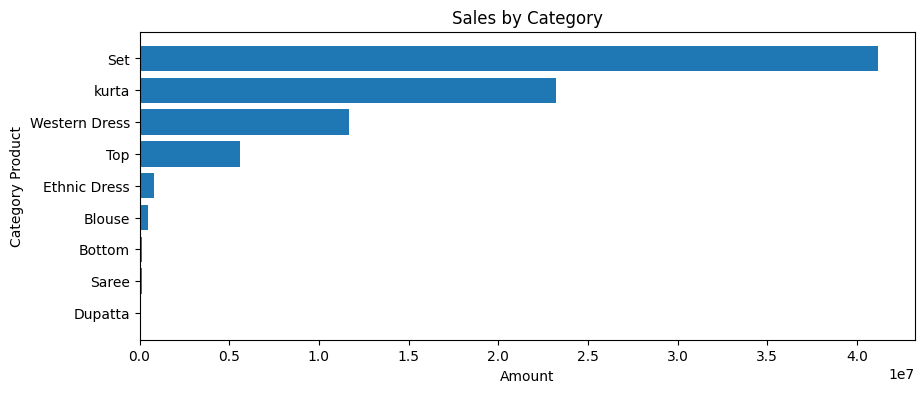


Interpretasi:
- Category dengan kontribusi terbesar terhadap penjualan adalah Set, dengan niai penjualan mencapai 41 juta Rupee jauh dari nilai penjualan kategori lain
- Category dengan kontribusi terkecil terhadap penjualan adalah Dupatta, dengan nilai penjualan sebesar 610 Rupee


In [25]:
#melakukan grouping data berdasarkan category dan aggregation dengan menghitung total penjualan
categorySales=df.groupby('category')['amount'].sum().reset_index().sort_values('amount',ascending=False)
print("      Sales by Category")
print("-----------------------------")
print(categorySales)

#membuat plot (horizontal bar chart) untuk mengetahui kontribusi masing-masing category terhadap penjualan 
plt.figure(figsize=(10,4))
plt.barh(categorySales['category'],categorySales['amount'])
plt.gca().invert_yaxis()
plt.title('Sales by Category')
plt.xlabel('Amount')
plt.ylabel('Category Product')
plt.show()

print("\nInterpretasi:")
print("- Category dengan kontribusi terbesar terhadap penjualan adalah Set, dengan niai penjualan mencapai 41 juta Rupee jauh dari nilai penjualan kategori lain")
print("- Category dengan kontribusi terkecil terhadap penjualan adalah Dupatta, dengan nilai penjualan sebesar 610 Rupee")


Top 10 State by Sales

        Sales by Ship State        
-----------------------------------
           ship_state       amount
20        MAHARASHTRA  14052730.14
15          KARNATAKA  11044369.37
31          TELANGANA   7335880.65
33      UTTAR PRADESH   7234164.08
30         TAMIL NADU   6923420.11
8               DELHI   4637942.41
16             KERALA   4092192.58
35        WEST BENGAL   3758955.44
1      ANDHRA PRADESH   3447311.72
11            HARYANA   3019427.99
10            GUJARAT   2931931.82
28          RAJASTHAN   1871846.16
19     MADHYA PRADESH   1690392.98
4               BIHAR   1506968.32
25             ODISHA   1471677.39
27             PUNJAB   1279473.84
3               ASSAM   1087711.20
34        UTTARAKHAND   1039483.55
14          JHARKHAND    982008.21
9                 GOA    671565.85
6        CHHATTISGARH    597710.83
12   HIMACHAL PRADESH    542084.51
13    JAMMU & KASHMIR    488997.74
21            MANIPUR    223056.99
5          CHANDIGARH    220815.67
26         PUDUCHE

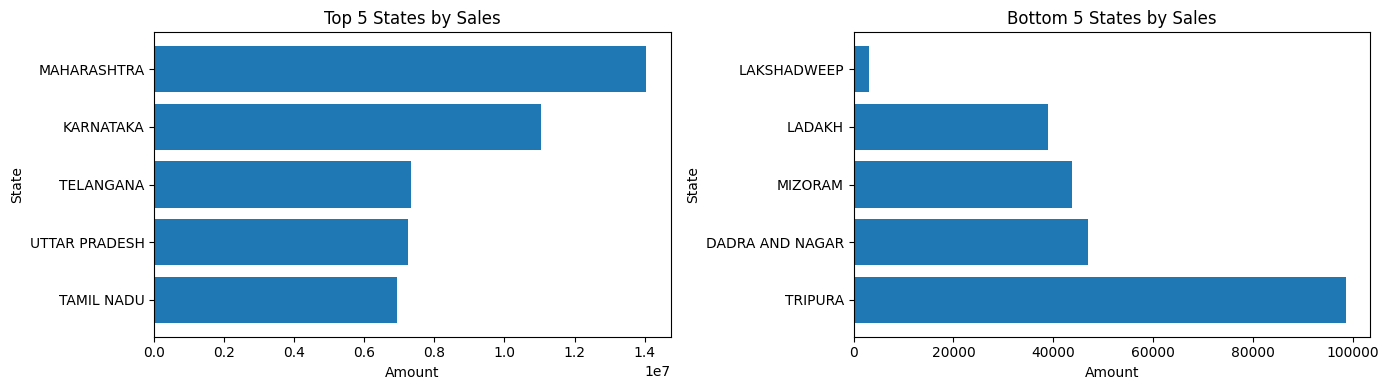


Interpretasi:
- Penjualan cenderung terkonsentrasi secara geografis, dengan lima wilayah teratas menyumbang X% dari total sales. Maharashtra menjadi kontributor terbesar dengan sales sebesar 13,9 juta Rupee
- Wilayah dengan nilai penjualan terkecil adalah Wilayah Lakshadweep, yaitu senilai 3,1 ribu Rupee


In [ ]:
#melakukan grouping data berdasarkan ship state dan aggregation dengan menghitung total penjualan
stateSales=df.groupby('ship_state')['amount'].sum().reset_index().sort_values('amount',ascending=False)
print("        Sales by Ship State        ")
print("-----------------------------------")
print(stateSales)

#membuat plot untuk mengetahui 5 penjualan tertinggi dan terendah
fig, axes=plt.subplots(1,2,figsize=(14,4))

#top 5 states by sales
top5=stateSales.head(5).sort_values('amount')
top5Percentage=(top5['amount'].sum()/(stateSales['amount'].sum()))*100
print("\nPersentase distribusi Top 5 terhadap total penjualan:")
print(f"{top5Percentage:.1f}%")
axes[0].barh(top5['ship_state'],top5['amount'])
axes[0].set_title('Top 5 States by Sales')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('State')

#bottom 5 states by sales
bottom5=stateSales.tail(5)
axes[1].barh(bottom5['ship_state'],bottom5['amount'])
axes[1].set_title('Bottom 5 States by Sales')
axes[1].set_xlabel('Amount')
axes[1].set_ylabel('State')

plt.tight_layout()
plt.show()

print("\nInterpretasi:")
print("- Penjualan cenderung terkonsentrasi secara geografis, dengan 5 wilayah teratas menyumbang 55,9% dari total penjualan")
print("- Wilayah Maharashtra menjadi kontributor terbesar dengan penjualan sebesar 13,9 juta Rupee")
print("- Wilayah dengan nilai penjualan terkecil adalah Wilayah Lakshadweep, yaitu senilai 3,1 ribu Rupee")


Sales Performance by Fulfilment

   Sales by Fulfilment   
-------------------------
  fulfilment      amount
0     Amazon  57971320.0
1   Merchant  25313002.3


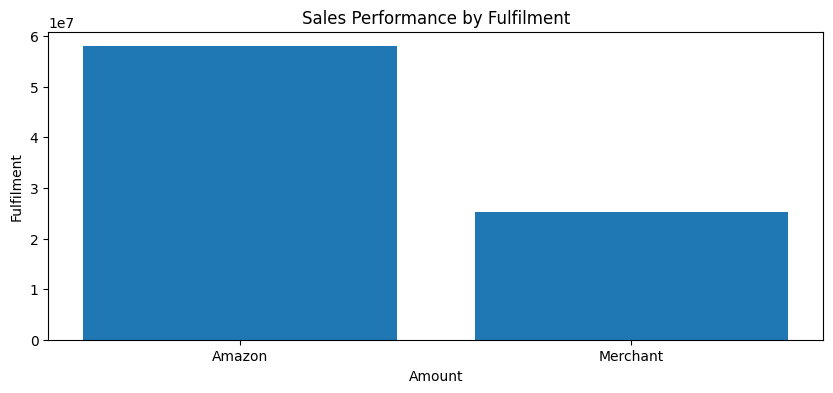


Interpretasi:
Metode fulfillment melalui Amazon mencatat sales sebesar 57,6 juta Rupee,
sekitar 2,3 kali lebih tinggi dibandingkan metode fulfillment melalui Merchant senilai 25,2 juta Rupee


In [29]:
#melakukan grouping data berdasarkan fulfilment dan aggregation dengan menghitung total penjualan
fulfilmentSales=df.groupby('fulfilment')['amount'].sum().reset_index().sort_values('amount',ascending=False)
print("   Sales by Fulfilment   ")
print("-------------------------")
print(fulfilmentSales)

#membuat plot (horizontal bar chart) untuk mengetahui kontribusi masing-masing category terhadap penjualan 
plt.figure(figsize=(10,4))
plt.bar(fulfilmentSales['fulfilment'],fulfilmentSales['amount'])
plt.title('Sales Performance by Fulfilment')
plt.xlabel('Amount')
plt.ylabel('Fulfilment')
plt.show()

print("\nInterpretasi:")
print("Metode fulfillment melalui Amazon mencatat sales sebesar 57,6 juta Rupee,")
print("sekitar 2,3 kali lebih tinggi dibandingkan metode fulfillment melalui Merchant senilai 25,2 juta Rupee")

Order Distribution by Courier Status


Order Distribution by Courier Status
------------------------------------
  courier_status  order_id
1        Shipped    116327
2      Unshipped      6679
0      Cancelled      5930


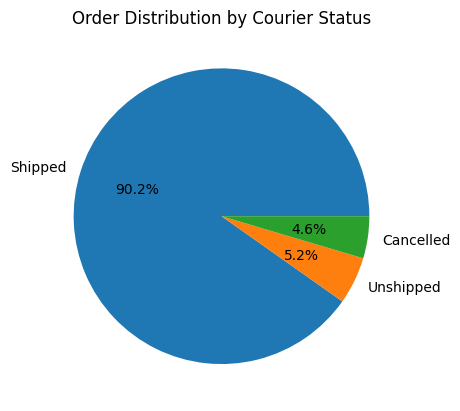


Interpretasi:
- Sebanyak 9,7% order belum terselesaikan, terdiri dari status unshipped (5,2%) dan cancelled (4,5%)
- Mayoritas status pengiriman transaksi adalah shipped (90,3%)


In [30]:
#melakukan grouping data berdasarkan courier status dan aggregation dengan menghitung jumlah order distribution
orderStatus=df.groupby('courier_status')['order_id'].count().reset_index().sort_values('order_id',ascending=False)
print("\nOrder Distribution by Courier Status")
print("------------------------------------")
print(orderStatus)

#membuat plot (pie chart) untuk mengetahui distribusi order id berdasarkan status kurir
plt.pie(orderStatus['order_id'],labels=orderStatus['courier_status'],autopct='%1.1f%%')
plt.title('Order Distribution by Courier Status')
plt.show()

print("\nInterpretasi:")
print("- Sebanyak 9,7% order belum terselesaikan, terdiri dari status unshipped (5,2%) dan cancelled (4,5%)")
print("- Mayoritas status pengiriman transaksi adalah shipped (90,3%)")

<b>Temuan:</b>
- Penjualan mengalami penurunan setelah mencapai puncak penjualan pada Bulan April senilai 30,6 juta Rupee, menjadi 24,8 juta Rupee pada Bulan Juni
- Kategori Set menjadi kontributor penjualan terbesar senilai 41 juta Rupee, jauh lebih tinggi dibandingkan kategori lainnya
- Maharashtra menjadi wilayah dengan penjualan terbesar, yaitu sekitar 13,9 juta Rupee
- Terdapat perbedaan nilai penjualan yang cukup signifikan antara wilayah dengan penjualan tertinggi dan terendah
- Fulfillment melalui Amazon mencatat penjualan sebesar 57,6 juta Rupee, sekitar 2,3 kali dibandingkan fulfillment melalui Merchant sebesar 25,2 juta Rupee
- Sebanyak 9,7% order berada pada courier status unshipped atau cancelled, terdiri dari 5,2% unshipped dan 4,5% cancelled

# 6. Multivariate Analysis